# Unsupervised Evaluation of Supervised vs Self-Supervised Models

This notebook mirrors the runner/model loading style used in your other notebooks and evaluates embeddings with unsupervised criteria.

It computes:
- KMeans clustering quality (`silhouette`, `ARI`, `NMI`)
- Cluster-to-label aligned metrics (`accuracy`, `macro F1`) via Hungarian matching
- A feature separability proxy using 5-fold KNN classification on frozen embeddings

In [1]:
import sys
sys.path.append('/workspace')
sys.path.append('/workspace/src')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.optimize import linear_sum_assignment

from src.models.config import Config
from src.supervised_runner import SupervisedRunner
from src.semi_supervised_runner import SemiSupervisedRunner
from src.self_supervised_runner import SelfSupervisedRunner

os.chdir('/workspace')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
def load_model(train_type, run_folder_path, load_dataloaders=False):
    run_folder_path = str(run_folder_path)
    config_path = os.path.join(run_folder_path, 'config.txt')
    if not os.path.exists(config_path):
        raise FileNotFoundError(f'Config file not found at {config_path}')

    config = Config.from_txt(config_path)

    if train_type == 'supervised':
        runner = SupervisedRunner(config, 'single')
    elif train_type == 'semi_supervised':
        runner = SemiSupervisedRunner(config, 'single')
    elif train_type == 'self_supervised':
        runner = SelfSupervisedRunner(config, 'single')
    else:
        raise ValueError(f'Invalid train type: {train_type}')

    checkpoint_candidates = [
        os.path.join(run_folder_path, 'checkpoints', 'best_model.ckpt'),
        os.path.join(run_folder_path, 'checkpoints', 'last.ckpt'),
    ]
    checkpoint_path = next((p for p in checkpoint_candidates if os.path.exists(p)), None)
    if checkpoint_path is None:
        raise FileNotFoundError(
            f'No checkpoint found in {os.path.join(run_folder_path, "checkpoints")}. '
            f'Tried: {checkpoint_candidates}'
        )

    model = runner.load_model_from_checkpoint(checkpoint_path)

    if not load_dataloaders:
        return model

    if runner._type() == 'supervised':
        labeled_dataloader, _, _ = runner.load_dataloaders(
            runner.labeled_data_df,
            pd.DataFrame(),
            pd.DataFrame(),
            runner.unlabeled_data_df,
        )
        return model, labeled_dataloader

    labeled_dataloader, _, _, unlabeled_dataloader = runner.load_dataloaders(
        runner.labeled_data_df,
        pd.DataFrame(),
        pd.DataFrame(),
        runner.unlabeled_data_df,
    )
    return model, (labeled_dataloader, unlabeled_dataloader)


def get_candidate_run_paths():
    base = Path('/workspace/runs/single')

    supervised_unsup = base / 'supervised' / 'resnet18' / 'unsupervised_run'

    self_sup_base = base / 'self_supervised' / 'simclr' / 'resnet18'
    self_sup_candidates = sorted(
        [p for p in self_sup_base.glob('*') if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    self_sup_latest = self_sup_candidates[0] if self_sup_candidates else None

    return {
        'supervised_unsupervised_run': supervised_unsup,
        'self_supervised_unsupervised_run': self_sup_latest,
    }


candidate_paths = get_candidate_run_paths()
for k, v in candidate_paths.items():
    print(f'{k}: {v}')

supervised_unsupervised_run: /workspace/runs/single/supervised/resnet18/unsupervised_run
self_supervised_unsupervised_run: /workspace/runs/single/self_supervised/simclr/resnet18/unsupervised_run


In [3]:
def extract_embeddings(feature_extractor, dataloader):
    feature_extractor.eval()

    X = []
    y = []

    with torch.no_grad():
        for (_image_path, is_transformed, image_tensor, _extra_features, label) in tqdm(
            dataloader, desc='Extracting embeddings'
        ):
            x = image_tensor.to(device)
            if x.ndim == 4 and x.shape[1] == 1:
                x = x.repeat(1, 3, 1, 1)

            features = feature_extractor(x).detach().cpu().numpy()
            labels = label.detach().cpu().numpy()

            # Keep only original (non-augmented) views for fair comparisons.
            for i in range(len(labels)):
                keep = True
                if isinstance(is_transformed, torch.Tensor):
                    keep = not bool(is_transformed[i].item())
                else:
                    keep = not bool(is_transformed[i])
                if keep:
                    X.append(features[i])
                    y.append(int(labels[i]))

    return np.asarray(X), np.asarray(y)


def kmeans_label_alignment_metrics(X, y, n_clusters, random_state=44):
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
    cluster_ids = kmeans.fit_predict(X)

    sil = silhouette_score(X, cluster_ids)
    ari = adjusted_rand_score(y, cluster_ids)
    nmi = normalized_mutual_info_score(y, cluster_ids)

    cm = confusion_matrix(y, cluster_ids)
    row_ind, col_ind = linear_sum_assignment(-cm)
    cluster_to_label = {cluster: label for label, cluster in zip(row_ind, col_ind)}
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids], dtype=np.int64)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')

    return {
        'silhouette': float(sil),
        'ari': float(ari),
        'nmi': float(nmi),
        'cluster_aligned_accuracy': float(acc),
        'cluster_aligned_macro_f1': float(f1),
    }


def knn_cv_scores(X, y, n_splits=5, n_neighbors=5, random_state=44):
    n_splits = min(n_splits, int(np.min(np.bincount(y))))
    cv = StratifiedKFold(n_splits=max(2, n_splits), shuffle=True, random_state=random_state)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    acc_scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(knn, X, y, cv=cv, scoring='f1_macro')

    return {
        'knn_cv_accuracy_mean': float(acc_scores.mean()),
        'knn_cv_accuracy_std': float(acc_scores.std()),
        'knn_cv_macro_f1_mean': float(f1_scores.mean()),
        'knn_cv_macro_f1_std': float(f1_scores.std()),
    }

In [7]:
# You can override these manually if needed.
SUPERVISED_RUN_PATH = candidate_paths['supervised_unsupervised_run']
SELF_SUPERVISED_RUN_PATH = candidate_paths['self_supervised_unsupervised_run']

print('SUPERVISED_RUN_PATH =', SUPERVISED_RUN_PATH)
print('SELF_SUPERVISED_RUN_PATH =', SELF_SUPERVISED_RUN_PATH)

SUPERVISED_RUN_PATH = /workspace/runs/single/supervised/resnet18/unsupervised_run
SELF_SUPERVISED_RUN_PATH = /workspace/runs/single/self_supervised/simclr/resnet18/unsupervised_run


In [8]:
loaded_models = {}

for model_tag, train_type, path in [
    ('supervised', 'supervised', SUPERVISED_RUN_PATH),
    ('self_supervised', 'self_supervised', SELF_SUPERVISED_RUN_PATH),
]:
    if path is None:
        print(f'[SKIP] {model_tag}: no run path available')
        continue

    try:
        model, loaders = load_model(train_type, str(path), load_dataloaders=True)
        if train_type == 'supervised':
            labeled_loader = loaders
        else:
            labeled_loader = loaders[0]

        loaded_models[model_tag] = {
            'model': model,
            'labeled_loader': labeled_loader,
            'run_path': str(path),
        }
        print(f'[OK] {model_tag}: loaded from {path}')
    except Exception as e:
        print(f'[SKIP] {model_tag}: {e}')

print('Loaded:', list(loaded_models.keys()))

Seed set to 44


Random seeds set to 44 for reproducibility


Seed set to 44


Blocks to freeze: [Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [9]:
rows = []
embeddings_cache = {}

for model_tag, payload in loaded_models.items():
    model = payload['model']
    labeled_loader = payload['labeled_loader']

    feature_extractor = model.feature_extractor.to(device)
    X, y = extract_embeddings(feature_extractor, labeled_loader)

    if X.shape[0] < 10:
        print(f'[SKIP] {model_tag}: too few samples ({X.shape[0]})')
        continue

    n_classes = len(np.unique(y))
    unsup_metrics = kmeans_label_alignment_metrics(X, y, n_clusters=n_classes)
    knn_metrics = knn_cv_scores(X, y, n_splits=5, n_neighbors=5)

    merged = {
        'model_tag': model_tag,
        'n_samples': int(X.shape[0]),
        'embedding_dim': int(X.shape[1]),
        **unsup_metrics,
        **knn_metrics,
    }
    rows.append(merged)
    embeddings_cache[model_tag] = {'X': X, 'y': y}

results_df = pd.DataFrame(rows).sort_values(by='cluster_aligned_macro_f1', ascending=False)
results_df

Extracting embeddings: 100%|██████████| 74/74 [00:11<00:00,  6.34it/s]


,model_tag,n_samples,embedding_dim,silhouette,ari,nmi,cluster_aligned_accuracy,cluster_aligned_macro_f1,knn_cv_accuracy_mean,knn_cv_accuracy_std,knn_cv_macro_f1_mean,knn_cv_macro_f1_std
0,supervised,589,64,0.064288,0.239405,0.369010,0.475382,0.458201,0.592496,0.023926,0.533651,0.024579
1,self_supervised,589,64,0.256773,0.085034,0.263585,0.242784,0.141486,0.650239,0.030196,0.589362,0.030361


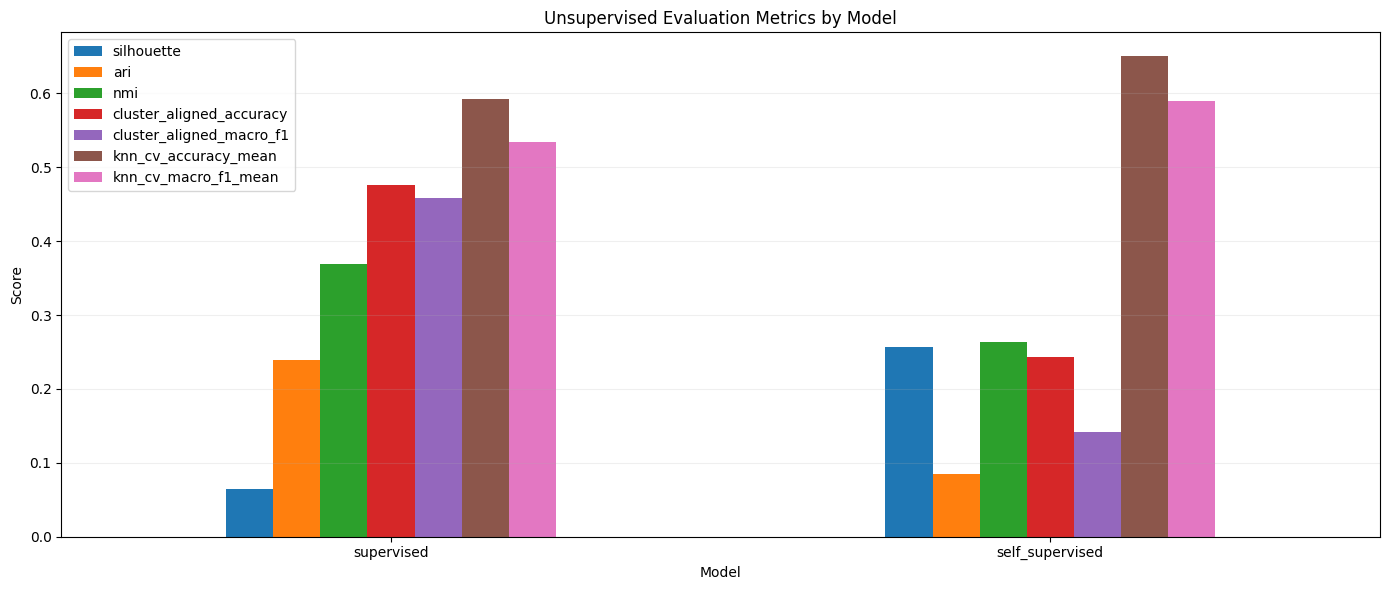

In [10]:
if not results_df.empty:
    cols = [
        'silhouette',
        'ari',
        'nmi',
        'cluster_aligned_accuracy',
        'cluster_aligned_macro_f1',
        'knn_cv_accuracy_mean',
        'knn_cv_macro_f1_mean',
    ]

    ax = results_df.set_index('model_tag')[cols].plot(
        kind='bar',
        figsize=(14, 6),
        rot=0,
        title='Unsupervised Evaluation Metrics by Model',
    )
    ax.set_ylabel('Score')
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('No models were evaluated. Check checkpoint availability and run paths.')

## Notes

- `silhouette`, `ARI`, and `NMI` are label-free/cluster quality metrics (ARI/NMI use labels for evaluation only).
- `cluster_aligned_accuracy` and `cluster_aligned_macro_f1` map cluster IDs to class IDs using Hungarian matching.
- `knn_cv_*` metrics are a separability proxy on frozen embeddings (not end-to-end model training).

If you want, I can add UMAP/t-SNE visualization of the embeddings for both models in the same notebook.